In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../../dataset/prepared/final_preprocessed_8PCs.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,FP_IDX,FP_AMP1,FP_AMP2,CIR_PWR,MAX_NOISE,RXPACC,PREAM_LEN,CIR_PC1,CIR_PC2,CIR_PC3,CIR_PC4,CIR_PC5,CIR_PC6,CIR_PC7,CIR_PC8,RANGE
0,745.0,18712.0,10250.0,11855.0,967.0,611.0,1024.0,-10.899240,21.536682,-1.663086,-9.069089,-6.491534,-2.442977,-6.911036,-8.475677,3.90
1,749.0,11239.0,6313.0,18968.0,1133.0,447.0,1024.0,28.390261,-54.587130,-34.088007,-11.310028,-6.324734,-2.996781,2.770749,-1.643189,0.66
2,746.0,17845.0,18095.0,11380.0,1744.0,276.0,1024.0,55.250058,56.398613,22.352259,-9.362803,-8.034061,-17.334001,-0.793633,23.452083,1.19
3,748.0,18991.0,19444.0,13006.0,3904.0,283.0,1024.0,80.200057,13.423382,40.347520,-19.820667,7.579159,-11.896430,-12.592022,-1.772267,0.28
4,744.0,14781.0,10399.0,8025.0,1035.0,272.0,1024.0,20.229733,58.397655,-40.727859,16.409829,-12.187324,2.244173,-3.831716,16.710905,1.23


In [24]:
X = df.drop(columns=["RANGE"])
y = df["RANGE"]


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

Neural Network Regression Performance on Test Set:
Mean Absolute Error: 5.123732892772155
Mean Squared Error: 38.276505398264305
R-squared: -12.907737897891291


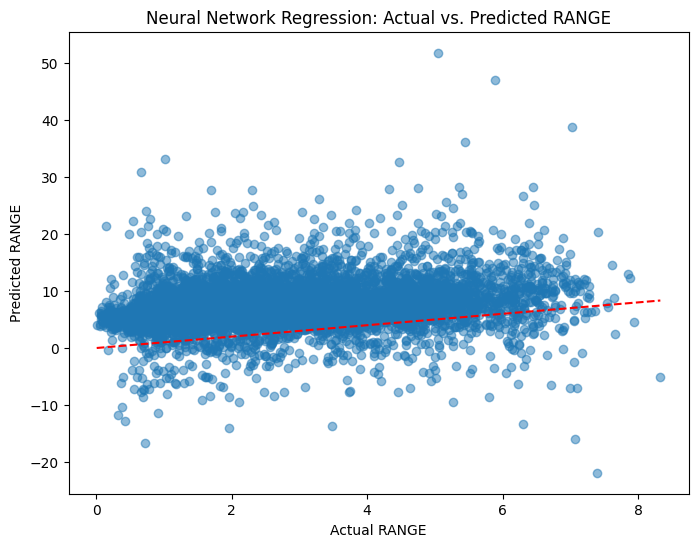

In [26]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Create and train the Neural Network Regressor
# Here we use one hidden layer with 100 neurons and allow up to 500 iterations.
nn_reg = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=111)
nn_reg.fit(X_train, y_train)

# 2. Predict on the test set
y_pred_nn = nn_reg.predict(X_test)

# 3. Evaluate the performance
mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network Regression Performance on Test Set:")
print("Mean Absolute Error:", mae_nn)
print("Mean Squared Error:", mse_nn)
print("R-squared:", r2_nn)

# 4. Plot Actual vs. Predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_nn, alpha=0.5)
plt.xlabel("Actual RANGE")
plt.ylabel("Predicted RANGE")
plt.title("Neural Network Regression: Actual vs. Predicted RANGE")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


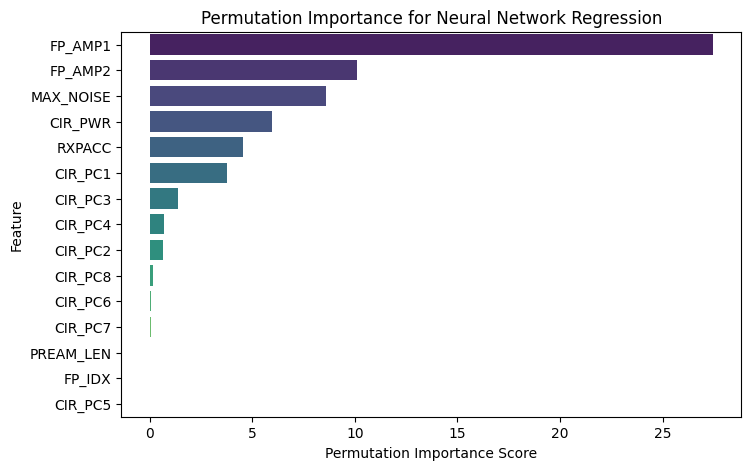

In [27]:
from sklearn.inspection import permutation_importance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute permutation importance for the neural network regressor
r = permutation_importance(nn_reg, X_test, y_test, n_repeats=10, random_state=111, scoring='neg_mean_squared_error')

# Convert the importances to a Pandas Series using feature names from X_test.columns
perm_importances = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

# Plot the permutation importances using a bar plot with hue assigned
plt.figure(figsize=(8,5))
ax = sns.barplot(x=perm_importances.values, 
                 y=perm_importances.index, 
                 hue=perm_importances.index, 
                 palette="viridis", 
                 dodge=False)

# Remove the legend if it exists
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Permutation Importance Score")
plt.ylabel("Feature")
plt.title("Permutation Importance for Neural Network Regression")
plt.show()


- Based on feature importance, can remove **PREAM_LEN, FP_IDX, CIR_PC5** (for dataset final_preprocessed_8PCs.cvs)

    - Mean Absolute Error: 5.123732892772155
    - Mean Squared Error: 38.276505398264305
    - R-squared: -12.907737897891291
  
- Based on feature importance, can remove **CIR_PC3/7** (for dataset final_preprocessed_8PCs_both.cvs)
    - Mean Absolute Error: 8.211980523861367
    - Mean Squared Error: 92.6675310742365
    - R-squared: -15.642694581657238

- Based on feature importance, can remove **STDEV_NOISE, NLOS, CIR_PC2/3/4/5/6/7/8, PREAM_LEN, FP_IDX** (for dataset final_preprocessed_8PCs_both_all.cvs)
  **(WORST ONE I FEEL)**
    - Mean Absolute Error: 11.959235352460883
    - Mean Squared Error: 172.71936878498434
    - R-squared: -30.019664274019835